# Airbnb Market Intelligence

## 01 - Univariate Exploratory Data Analysis (EDA)

### Objectives

- Load cleaned Airbnb dataset
- Understand dataset structure
- Analyze numerical variables
- Analyze categorical variables
- Generate univariate visualizations

## 02 - Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## 03 - Load Dataset

In [2]:
listings = pd.read_csv("../data/cleaned/listings_cleaned.csv")

print("Shape:", listings.shape)

listings.head()

Shape: (279712, 32)


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


## 04 - Dataset Information

In [3]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279712 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                279712 non-null  object 
 5   host_response_time           279712 non-null  object 
 6   host_response_rate           279712 non-null  float64
 7   host_acceptance_rate         279712 non-null  float64
 8   host_is_superhost            279712 non-null  object 
 9   host_total_listings_count    279712 non-null  float64
 10  host_has_profile_pic         279712 non-null  object 
 11  host_identity_verified       279712 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

## 05 - Missing Values

In [4]:
missing = listings.isnull().sum()

missing = missing[missing > 0]

missing

host_since    165
dtype: int64

## 06 - Summary Statistics

In [5]:
listings.describe().T

,count,mean,std,min,25%,50%,75%,max
listing_id,279712.0,2.638196e+07,1.442576e+07,2577.00000,1.384462e+07,2.767098e+07,3.978485e+07,4.834353e+07
host_id,279712.0,1.081658e+08,1.108570e+08,1822.00000,1.720656e+07,5.826911e+07,1.832853e+08,3.901874e+08
host_response_rate,279712.0,9.276617e-01,2.188783e-01,0.00000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
host_acceptance_rate,279712.0,8.889579e-01,2.354755e-01,0.00000,9.500000e-01,9.800000e-01,1.000000e+00,1.000000e+00
host_total_listings_count,279712.0,2.456770e+01,2.839579e+02,0.00000,1.000000e+00,1.000000e+00,4.000000e+00,7.235000e+03
latitude,279712.0,1.876186e+01,3.256034e+01,-34.26440,-2.296439e+01,4.071079e+01,4.190861e+01,4.890491e+01
longitude,279712.0,1.259508e+01,7.308131e+01,-99.33963,-4.319804e+01,2.382780e+00,2.898673e+01,1.513398e+02
accommodates,279712.0,3.288736e+00,2.133379e+00,0.00000,2.000000e+00,2.000000e+00,4.000000e+00,1.600000e+01
bedrooms,279712.0,1.461260e+00,1.102133e+00,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,5.000000e+01
price,279712.0,6.087927e+02,3.441827e+03,0.00000,7.500000e+01,1.500000e+02,4.740000e+02,6.252160e+05


## 07 - Categorical Summary

In [6]:
listings.describe(include="object").T

,count,unique,top,freq
name,279712,265861,Unknown Listing,175
host_since,279547,4240,2019-09-02,710
host_location,279712,7160,"Paris, Ile-de-France, France",47794
host_response_time,279712,5,Unknown,128782
host_is_superhost,279712,2,f,229459
host_has_profile_pic,279712,2,t,278796
host_identity_verified,279712,2,t,201191
neighbourhood,279712,660,I Centro Storico,14874
city,279712,10,Paris,64690
property_type,279712,144,Entire apartment,138989


## 08 - Price Distribution

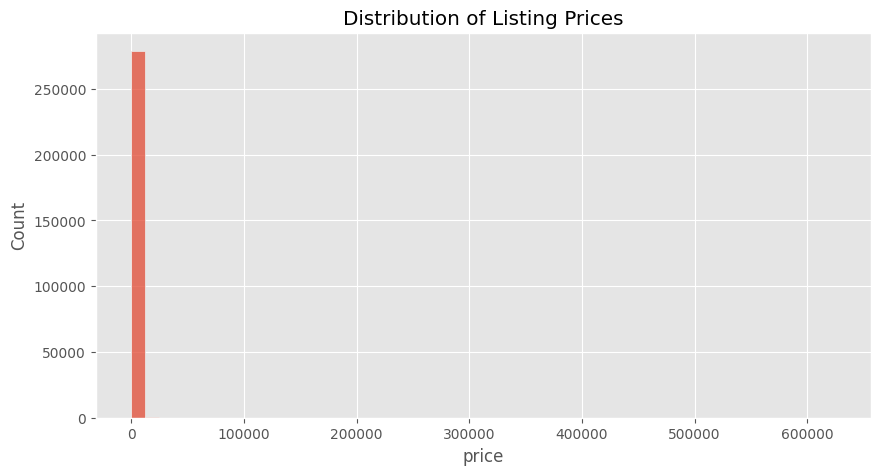

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(
    listings["price"],
    bins=50
)

plt.title("Distribution of Listing Prices")

plt.show()

## 09 - Bedrooms Distribution

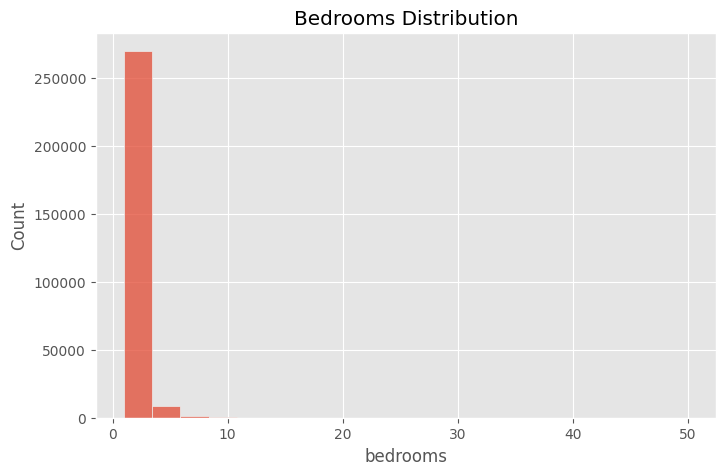

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    listings["bedrooms"],
    bins=20
)

plt.title("Bedrooms Distribution")

plt.show()

## 10 — Room Type

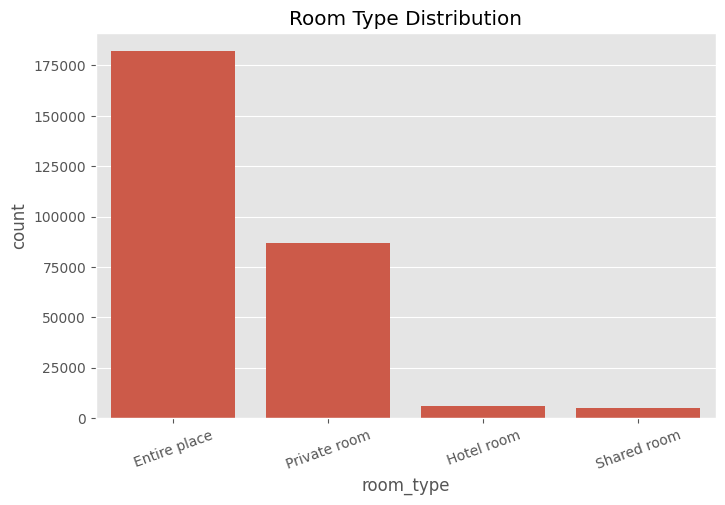

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=listings,
    x="room_type"
)

plt.xticks(rotation=20)

plt.title("Room Type Distribution")

plt.show()

## 11 — Property Type

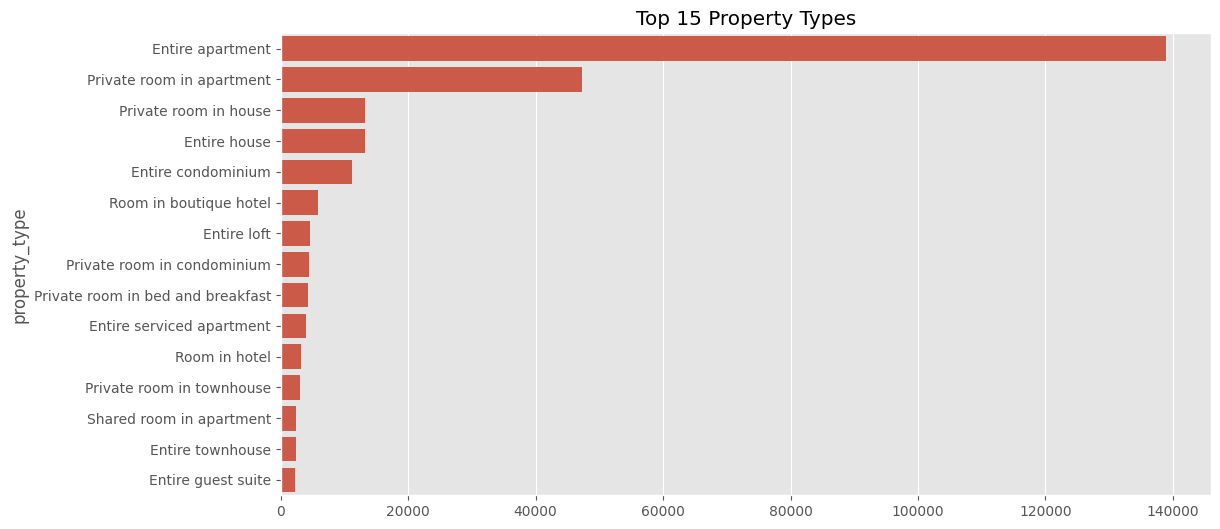

In [10]:
plt.figure(figsize=(12,6))

top = listings["property_type"].value_counts().head(15)

sns.barplot(
    x=top.values,
    y=top.index
)

plt.title("Top 15 Property Types")

plt.show()

## 12 — City Distribution

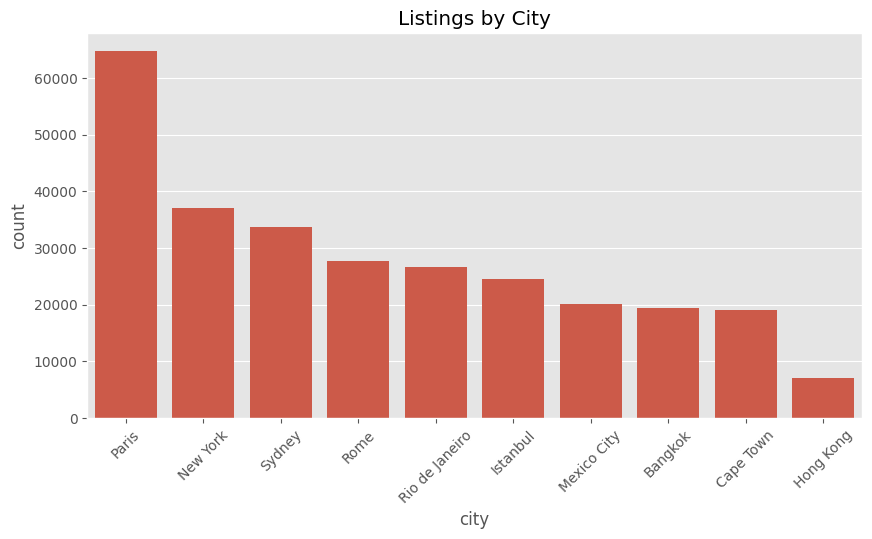

In [11]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=listings,
    x="city",
    order=listings["city"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Listings by City")

plt.show()

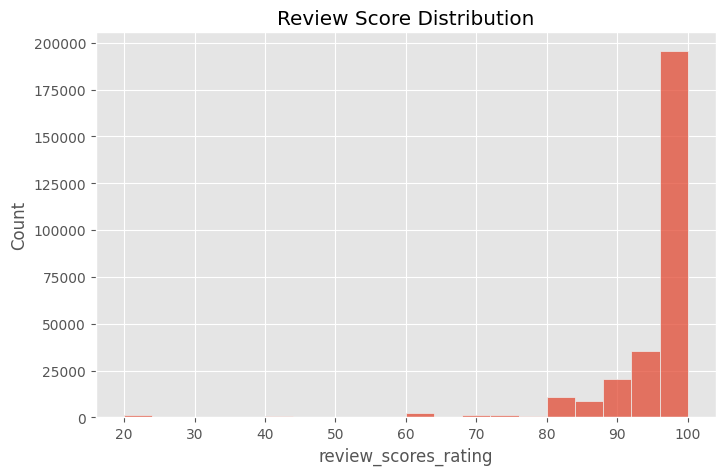

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    listings["review_scores_rating"],
    bins=20
)

plt.title("Review Score Distribution")

plt.show()

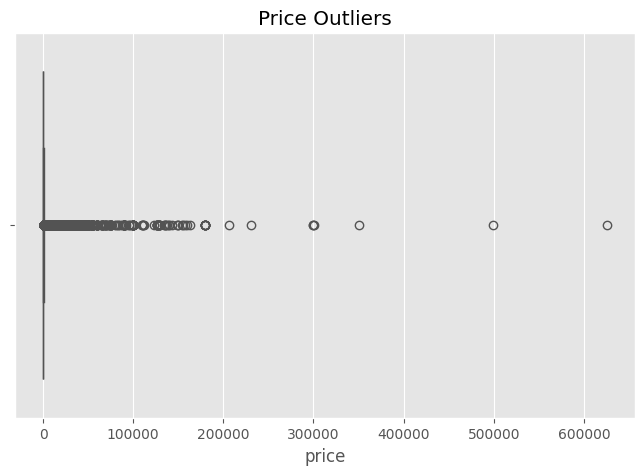

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=listings["price"]
)

plt.title("Price Outliers")

plt.show()

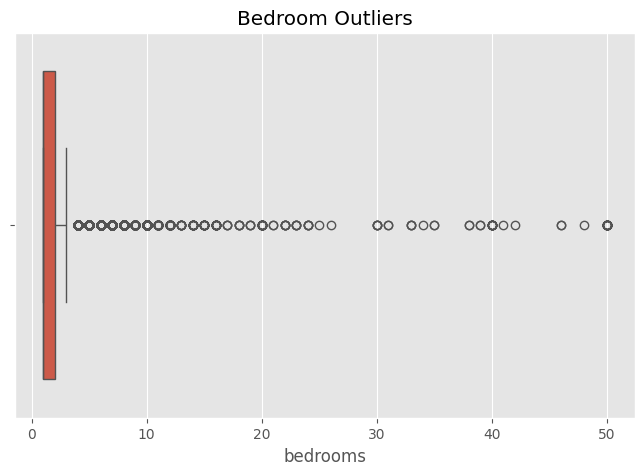

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=listings["bedrooms"]
)

plt.title("Bedroom Outliers")

plt.show()

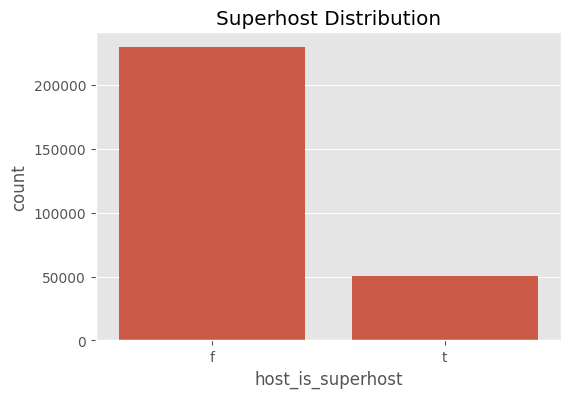

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=listings,
    x="host_is_superhost"
)

plt.title("Superhost Distribution")

plt.show()

## 17 - Instant Bookable Distribution

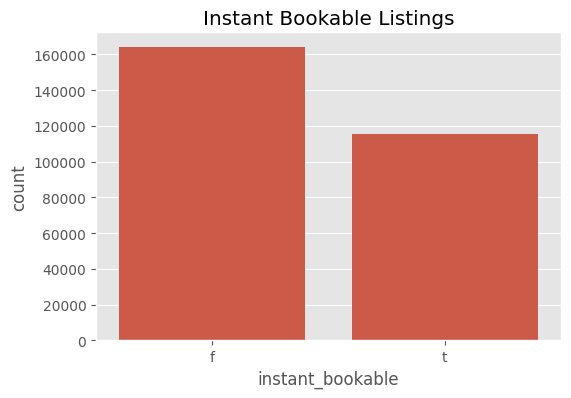

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=listings,
    x="instant_bookable"
)

plt.title("Instant Bookable Listings")

plt.show()

# Key Findings

- Dataset contains 279,712 Airbnb listings.
- Prices show a right-skewed distribution.
- Most properties have 1–2 bedrooms.
- Entire home/apartment is the dominant room type.
- A few property types dominate the market.
- Most review scores are very high (close to 10).
- Significant price outliers are present.